Importing the Dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading the data from the keras.datasets



In [3]:
(X_train,Y_train),(X_test, Y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(X_train.shape,Y_train.shape,X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)




*   Training data ---- 60,000
*   Testing data ----- 10,000




Dimension ---- (28,28) ------- hence it is a Grayscale images

In [5]:
#printing the image
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [6]:
print(X_train[10].shape)

(28, 28)


All the images have the constant dimensions ------> (28,28)  or if not resize them






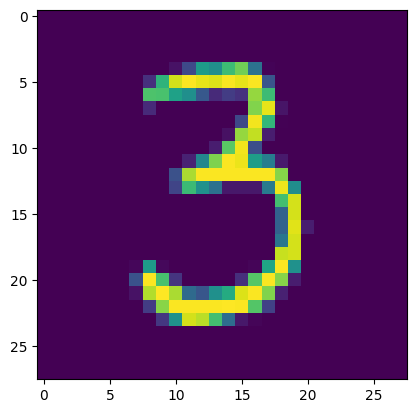

3


In [7]:
#displaying the image and its corresponding labels

plt.imshow(X_train[50])
plt.show()

#displaying the label
print(Y_train[50])

In [8]:
#images labels
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [10]:
#unqiue values in Y_train
print(np.unique(Y_train))

#unqiue values in Y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


We can use labels or we can apply one hot encoding ------ ([1 0 0 ...]  [0 1 0 0 ....], ....)

SCALING ----- DONE FOR BETTER ACCURACY

In [11]:
#scaling

X_train = X_train/255
X_test = X_test/255

In [13]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [16]:
#setting the layers for the neural network

model = keras.Sequential([
                        keras.layers.Flatten(input_shape=(28,28)),       #input layer (28,28) ----- Dimensions
                        keras.layers.Dense(50, activation='relu'),      #hidden layer
                        keras.layers.Dense(50, activation='relu'),      #hidden layer
                        keras.layers.Dense(10, activation='sigmoid')    #output layer (10) ------ labels ([0 1 2 ....... 9])
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
#complining

model.compile(
              optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [18]:
#training the model
model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8517 - loss: 0.5178
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9547 - loss: 0.1533
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9671 - loss: 0.1091
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9744 - loss: 0.0845
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9792 - loss: 0.0682
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9832 - loss: 0.0562
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9856 - loss: 0.0470
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0396
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9885 - loss: 0.0354
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9889 - loss: 0.0332


Accuracy on traing data --- 98.89 %

**Accuracy on test data**

In [19]:
(loss, accuracy) = model.evaluate(X_test, Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9660 - loss: 0.1235
0.9706000089645386


Test data accuracy ---- 97.06%

In [20]:
print(X_test.shape)

(10000, 28, 28)


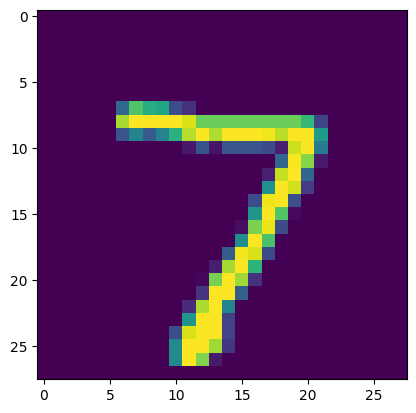

In [21]:
#first data point in x_test

plt.imshow(X_test[0])
plt.show()

In [22]:
#print its label
print(Y_test[0])

7


In [23]:
Y_pred= model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
print(Y_pred.shape)

(10000, 10)


**10 -----> labels predicted**

In [26]:
print(Y_pred[0])

[3.6665937e-03 5.2546343e-04 6.1175935e-02 3.4392473e-01 6.7309014e-07
 1.8447504e-04 3.9174224e-09 9.9999976e-01 3.8060240e-02 6.8332654e-01]


model.predict() -----> this gives the probability for the prediction

In [27]:
#converting the prediction probability for class labels

label_for_first_test_img= np.argmax(Y_pred[0])

print(label_for_first_test_img)

7


In [31]:
#converting the prediction probability for all the class labels
Y_pred_labels= [np.argmax(i) for i in Y_pred]

print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

1. Y_test --- > true labels
2. Y_pred_labels ---- > predicted labels

CONFUSION MATRIX

In [32]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)
print(conf_mat)

tf.Tensor(
[[ 965    0    1    0    0    0    4    0    3    7]
 [   1 1120    3    2    0    1    7    0    1    0]
 [   8    5  977    5    5    0    9   12   10    1]
 [   0    1    2  980    0   11    0    5    7    4]
 [   1    0    0    0  967    0    8    2    0    4]
 [   2    0    0   12    4  853    7    1   11    2]
 [   3    3    0    1    4    5  937    0    3    2]
 [   1    3    5    0    5    0    0  998    4   12]
 [   3    0    3    3    8    6    5    1  934   11]
 [   2    3    0    3   19    3    0    1    4  974]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

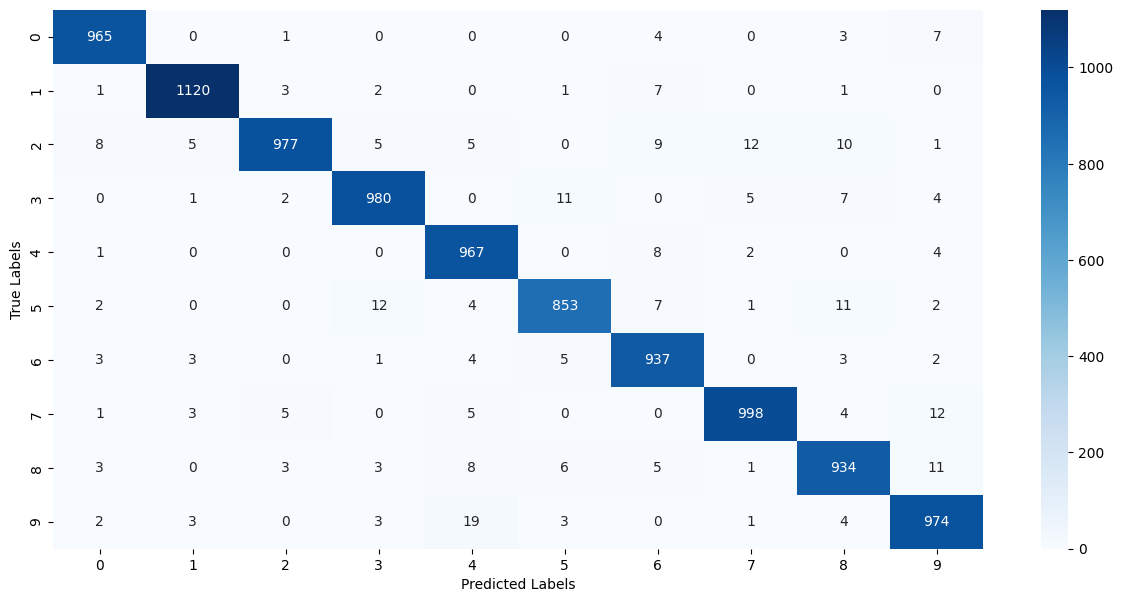

In [33]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

Building the predictive system


In [34]:
input_path='/content/MNIST_digit.png'
input_image=cv2.imread(input_path)

In [35]:
type(input_image)

numpy.ndarray

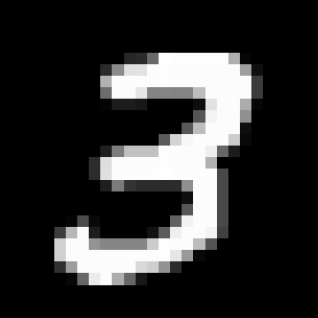

In [36]:
cv2_imshow(input_image)

In [37]:
input_image.shape

(318, 318, 3)

In [38]:
#converting the image to grayscale
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [39]:
#CHECKING THE DIMENSION
grayscale.shape

(318, 318)

In [42]:
#resizing the image to required dimension
input_image_resize=cv2.resize(grayscale, (28,28))

In [43]:
input_image_resize.shape

(28, 28)

In [44]:
cv2_imshow(input_image_resize)

In [45]:
#scaling the image
input_image_resize=input_image_resize/255

In [47]:
#reshaping the image
image_reshape=np.reshape(input_image_resize,[1,28,28])

In [48]:
#predicting
input_prediction = model.predict(image_reshape)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[6.0337187e-11 1.1805733e-05 1.4505445e-06 1.0000000e+00 2.3268632e-14
  1.8938254e-05 4.4587756e-20 6.4344550e-07 9.5726323e-01 2.5269252e-01]]


In [49]:
#converting the probability prediction to labels
input_data_label = np.argmax(input_prediction)
print(input_data_label)

3


**Predictive System**

Path of the image to be predicted :/content/MNIST_digit.png


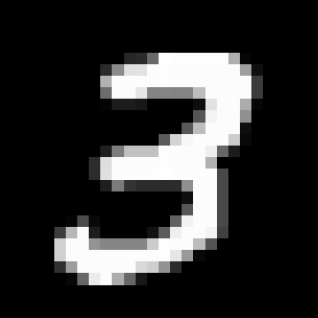

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The handWritten digit is predicted as : 3


In [50]:
input_path = input("Path of the image to be predicted :")

input_image=cv2.imread(input_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize=cv2.resize(grayscale, (28,28))

input_image_resize=input_image_resize/255

image_reshape=np.reshape(input_image_resize,[1,28,28])

input_prediction = model.predict(image_reshape)

input_data_label = np.argmax(input_prediction)

print("The handWritten digit is predicted as :",input_data_label)